# 5 · Where the course book takes you

**Prerequisite:** A first pass through Steps 1–4. **Destination:** Understand the purpose of every main chapter, how the topics connect, and what to check before and after studying them.

This is an outlook with small worked bridges. Implementing the advanced models and following their full derivations remains the work of the official chapters. Your immediate target was the linear-model chapter; the same foundations will now make later chapters easier to approach.

## 1. The three questions driving the book

**Foundational skills:** How do we represent data, measure mistakes, learn parameters, and quantify uncertainty?

**Models, especially generative models:** How do we construct useful representations and generate new samples or engineering designs?

**Engineering constraints:** How do we learn when simulations, measurements, or labels are expensive?

The book is organized around applications such as airfoil geometry, constitutive material models, topology optimization, and synthetic shape datasets. The probability distributions and mathematical tools are the common language across these applications.

## 2. A predictor, an autoencoder, and a generator

A **predictor** maps inputs to an output: force and temperature to deformation. An **autoencoder** maps data to a compact code and reconstructs them: geometry $x\to z\to\hat x$. A **generator** maps a source of randomness to a new sample: $z\sim N(0,I)$, then $x=g_\theta(z)$.

The hidden code $z$ is called **latent** because it is an internal representation rather than a directly observed target. Compression can make later modeling cheaper, but may discard important geometric details. A reconstruction objective and a useful engineering representation are not automatically the same goal.

A **conditional generator** also receives a desired condition $c$, such as a target response, and generates $g_\theta(z,c)$. Passing a condition into a model does not guarantee that a produced design satisfies physical constraints. Independent simulation or evaluation still matters.

### Checkpoint 1

Which task is prediction, which is reconstruction, and which is generation: estimate lift from an airfoil; encode an airfoil in ten numbers and rebuild it; create several different airfoils aimed at the same requested lift?

<details><summary>Worked answer</summary>

They are prediction, reconstruction, and conditional generation respectively. The third should allow diversity: different geometries can satisfy a similar desired response. A low reconstruction error does not by itself establish that samples from a chosen latent prior will look like valid airfoils.

</details>

## 3. GANs and optimal transport

A **generative adversarial network** trains a generator against a discriminator. The discriminator learns to distinguish real data from generated samples; its feedback trains the generator. The original minimax formulation is

$$\min_G\max_D E_{x\sim p_{data}}[\log D(x)]+E_{z\sim p_z}[\log(1-D(G(z)))].$$

The expectation notation means averaging over examples or generated noise. In practice, generators often use a different, non-saturating loss to improve gradients. Competing objectives create training challenges: one side can overpower the other, and the generator can miss modes of the data distribution.

**Mode collapse** means producing too little diversity. A sampler producing one excellent-looking shape repeatedly can still poorly represent the real collection of possible shapes. The following example does not train a GAN; it isolates what distribution coverage looks like.

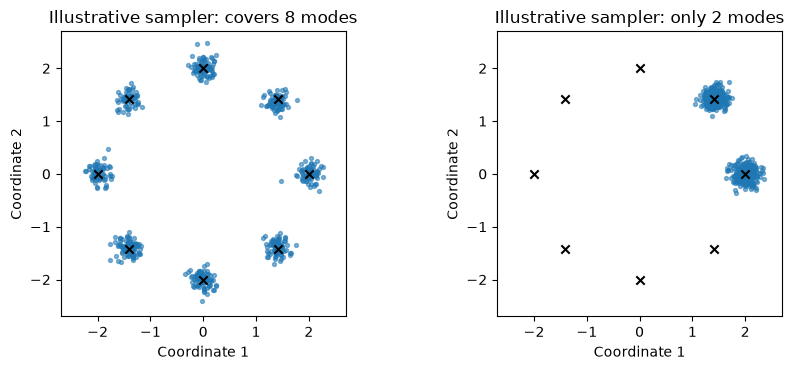

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(61)
angles = np.arange(8) * 2*np.pi/8
centres = 2*np.column_stack([np.cos(angles), np.sin(angles)])
full_labels = rng.integers(0, 8, 600)
collapsed_labels = rng.choice([0, 1], size=600)
full_samples = centres[full_labels] + rng.normal(0, 0.12, (600, 2))
collapsed_samples = centres[collapsed_labels] + rng.normal(0, 0.12, (600, 2))
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
for ax, samples, title in zip(axes, [full_samples, collapsed_samples],
                            ["Illustrative sampler: covers 8 modes", "Illustrative sampler: only 2 modes"]):
    ax.scatter(samples[:, 0], samples[:, 1], s=8, alpha=0.55)
    ax.scatter(centres[:, 0], centres[:, 1], marker="x", color="black", label="Target mode centres")
    ax.set(xlabel="Coordinate 1", ylabel="Coordinate 2", xlim=(-2.7, 2.7), ylim=(-2.7, 2.7), title=title)
    ax.set_aspect("equal")
fig.tight_layout(); plt.show()

**Optimal transport (OT)** compares the cost of moving mass from one distribution to another. For equally weighted one-dimensional samples, matching sorted samples minimizes the average absolute transport cost. Moving samples $[0,1]$ to $[2,3]$ this way costs $(2+2)/2=2$. In higher dimensions the matching is harder. Entropic regularization and Sinkhorn algorithms make certain transport problems more tractable; the course uses transport-based objectives for generative modeling.

What to watch in the official experiments: distribution coverage, discriminator/generator balance, and the effect of regularization. A training loss curve alone may not establish sample quality or diversity.

## 4. VAEs: reconstruct while organizing a probability model

A **variational autoencoder** learns an approximate encoder distribution $q_\phi(z\mid x)$ and a decoder observation model $p_\theta(x\mid z)$. The encoder does not just emit a fixed code: commonly it emits a Gaussian mean and standard deviation.

Its negative ELBO can be written

$$E_{q_\phi(z\mid x)}[-\log p_\theta(x\mid z)]+D_{KL}(q_\phi(z\mid x)\|p(z)).$$

The first term asks the sampled code to explain/reconstruct the observation under the decoder's likelihood. The second discourages an encoder distribution that departs too much from the chosen latent prior. For a suitable fixed-variance Gaussian decoder, the first term is proportional to squared reconstruction error plus constants.

To train through random sampling, write $z=\mu_\phi(x)+\sigma_\phi(x)\epsilon$, where $\epsilon\sim N(0,I)$. This is the **reparameterization trick**: the random source is separate, while the trainable transformation remains differentiable.

A deterministic autoencoder with excellent reconstructions need not give a latent space that supports sampling from a simple prior. The probabilistic objective explicitly addresses that modeling problem, with a reconstruction/regularization tradeoff.

### Checkpoint 2

Which earlier lessons are needed to understand the VAE objective? Why isn't it enough to make the KL term zero by ignoring the input?

<details><summary>Worked answer</summary>

You need distributions, conditional probability, expectations, negative log-likelihood, KL and the chain rule. An encoder equal to the prior can eliminate KL but may discard information needed for reconstruction. The total objective balances both terms. In some trained VAEs, a decoder can learn to ignore the latent code, a failure called posterior collapse.

</details>

## 5. Flows: turn simple noise into structured data

A **normalizing flow** uses an invertible transformation $x=f(z)$, usually with the same input and output dimension. Probability is conserved as volumes stretch or shrink:

$$p_X(x)=p_Z(f^{-1}(x))\left|\det J_{f^{-1}}(x)\right|.$$

Equivalently, $\log p_X(f(z))=\log p_Z(z)-\log|\det J_f(z)|$. The Jacobian determinant comes from Step 3's local volume scaling; the logarithm and density come from Step 4.

For $x=2z+1$ and $z\sim N(0,1)$, the new distribution is $N(1,2^2)$. Doubling distances doubles the spread, so the density is divided by 2: $p_X(x)=\tfrac12p_Z((x-1)/2)$.

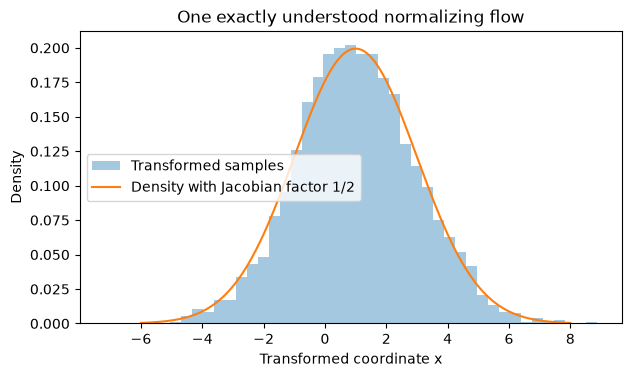

In [2]:
from scipy.stats import norm

z = rng.normal(size=4000)
transformed = 2*z + 1
grid = np.linspace(-6, 8, 300)
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.hist(transformed, bins=45, density=True, alpha=0.4, label="Transformed samples")
ax.plot(grid, 0.5*norm.pdf((grid-1)/2), label="Density with Jacobian factor 1/2")
ax.set(xlabel="Transformed coordinate x", ylabel="Density", title="One exactly understood normalizing flow")
ax.legend(); plt.show()

**Continuous normalizing flows** replace a sequence of transformations with an ODE, $dz/dt=v_\theta(z,t)$. Under suitable smoothness and invertibility conditions, log density along the trajectory evolves as $d\log p(z_t)/dt=-\nabla\cdot v_\theta$, the negative divergence of the velocity field. The divergence is the trace of its Jacobian. Numerical solvers approximate the trajectories; their accuracy and cost matter.

## 6. Scores, diffusion and flow matching

The **score** is $\nabla_x\log p(x)$. It differentiates with respect to a data location, not the model's weights. For a one-dimensional Gaussian, the score is $-(x-\mu)/\sigma^2$: it points towards the centre. A score field is not a classifier's score and is not a normalized density value.

**Score matching** learns such a field. Denoising score matching learns from deliberately perturbed observations. Sampling methods can combine movement in the score direction with noise; simply climbing towards a mode is not enough to reproduce a whole distribution.

**Diffusion models** work with multiple noise levels. A common forward construction is $x_t=\sqrt{\bar\alpha_t}x_0+\sqrt{1-\bar\alpha_t}\epsilon$, with Gaussian $\epsilon$. As $\bar\alpha_t$ gets small, the original structure is dominated by noise. The learned reverse procedure uses noise-level-dependent predictions to generate samples. Adding noise alone is not a trained generator.

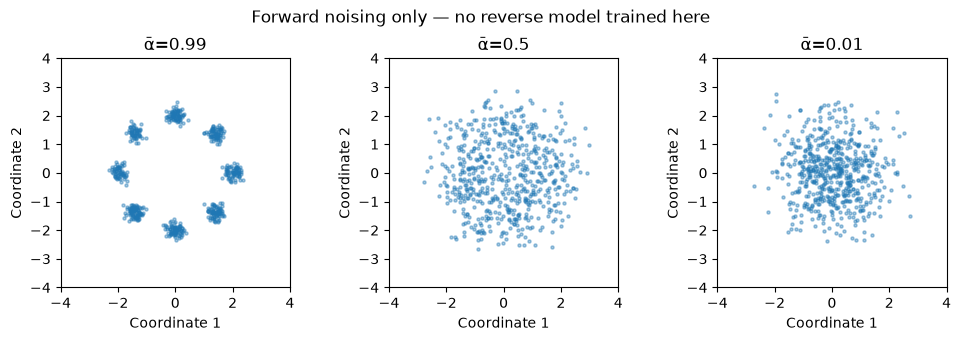

In [3]:
base = full_samples
noise = rng.normal(size=base.shape)
fig, axes = plt.subplots(1, 3, figsize=(10, 3.3))
for ax, alpha_bar in zip(axes, [0.99, 0.5, 0.01]):
    noisy = np.sqrt(alpha_bar)*base + np.sqrt(1-alpha_bar)*noise
    ax.scatter(noisy[:, 0], noisy[:, 1], s=5, alpha=0.4)
    ax.set(xlabel="Coordinate 1", ylabel="Coordinate 2", title=f"ᾱ={alpha_bar}",
           xlim=(-4, 4), ylim=(-4, 4))
    ax.set_aspect("equal")
fig.suptitle("Forward noising only — no reverse model trained here")
fig.tight_layout(); plt.show()

**Flow matching** learns a velocity field along a chosen probability path. For the simple interpolation $x_t=(1-t)z+tx$, a conditional target velocity is $x-z$. A network learns to predict the appropriate field from $x_t,t$, and sampling integrates its learned ODE. The noise/data coupling and path choice affect the method. Despite the similar names, this training objective differs from likelihood-based normalizing-flow training.

**Latent generative models** perform generation inside an encoded lower-dimensional space and then decode. This can reduce cost, while making the encoder/decoder's information loss another limitation to evaluate.

### Checkpoint 3

For $X\sim N(0,1)$, what is the score at $x=2$? For the interpolation from $z=0$ to $x=4$, where is $x_t$ at $t=0.25$ and what is its conditional velocity?

<details><summary>Worked answer</summary>

The score is −2. The interpolated point is $(1-0.25)0+0.25\times4=1$, and its velocity is $4-0=4$. The score describes local log-density change; the velocity describes a transport path. They are different mathematical objects even though both may be vector fields.

</details>

## 7. Reinforcement learning: choose actions over time

In reinforcement learning (RL), an agent observes a state, chooses an action, receives a reward and reaches a new state. It learns a **policy**, a rule or distribution for selecting actions. Rewards may be delayed, so optimizing the immediate reward alone can be wrong.

A discounted return is $G_t=r_t+\gamma r_{t+1}+\gamma^2r_{t+2}+\cdots$, with $0\leq\gamma<1$ in a common continuing-task setting. For rewards $[1,0,2]$ and $\gamma=0.9$, the return is $1+0+0.81\times2=2.62$.

The **value** of a state or state-action pair describes expected return. DQN learns action values with a neural network. Policy-gradient methods update a policy directly. Actor–critic combines a policy (actor) with a value estimate (critic). PPO constrains its policy-update objective to discourage overly large changes, but does not guarantee that all updates are safe or optimal.

The book compares DQN, REINFORCE, actor–critic and PPO on an Acrobot task. Watch exploration, noisy returns, and differences across seeds; one lucky episode is not a performance estimate.

## 8. Transformers: learn which other elements matter

For tokens or elements of a set, **attention** combines information from other elements using input-dependent weights. Queries $Q$ and keys $K$ produce similarities; a softmax converts each row of scores into nonnegative weights summing to one. Values $V$ are then averaged with those weights:

$$\operatorname{Attention}(Q,K,V)=\operatorname{softmax}(QK^T/\sqrt{d_k})V.$$

Softmax for scores $s_i$ is $e^{s_i}/\sum_j e^{s_j}$. Subtracting the row maximum before exponentiating improves numerical stability without changing the result. Consider precomputed attention scores $[2,0]$: their normalized weights are approximately $[0.881,0.119]$.

In [4]:
scores = np.array([[2., 0.], [1., 1.]])  # already-scaled example scores
values = np.array([[10., 0.], [0., 10.]])
exponentials = np.exp(scores - scores.max(axis=1, keepdims=True))
attention_weights = exponentials / exponentials.sum(axis=1, keepdims=True)
context = attention_weights @ values
print("Attention weights:\n", attention_weights.round(3))
print("Weighted value vectors:\n", context.round(3))
assert np.allclose(attention_weights.sum(axis=1), 1)

Attention weights:
 [[0.881 0.119]
 [0.5   0.5  ]]
Weighted value vectors:
 [[8.808 1.192]
 [5.    5.   ]]


A full transformer adds learned projections, multiple attention heads, nonlinear feed-forward layers, residual connections and normalization. Order or geometry may require positional information. Transformers are not restricted to language or autoregressive generation: this course also uses shape and point-cloud classification. Set handling and pooling determine whether a representation respects permutation symmetry.

## 9. Active and semi-supervised learning

**Active learning** asks which measurement or label to acquire next. A Gaussian process supplies a probabilistic distribution over functions and can express uncertainty away from observations. An uncertainty-based acquisition rule selects an informative next input according to the current model. High uncertainty is one possible criterion; the most uncertain point need not be the most useful for every engineering objective or cost structure.

**Semi-supervised learning** uses labeled and unlabeled data together. Label propagation uses a similarity structure to spread label information, relying on assumptions about how labels vary over nearby data. Incorrect neighborhood structure can spread errors rather than useful information.

### Checkpoint 4

How does choosing a new simulation input differ from using existing unlabeled geometries? Why can uncertainty sampling fail if a model is confidently wrong?

<details><summary>Worked answer</summary>

Choosing a new simulation is active learning: it changes which observations we acquire. Using existing unlabeled data alongside labeled examples is semi-supervised learning. If the uncertainty model is poorly calibrated or misspecified, a confidently wrong region may never be selected by pure uncertainty sampling. Acquisition rules need evaluation as well as the predictor itself.

</details>

## 10. Your chapter-by-chapter route

Chapter numbering and order follow the inspected `_quarto.yml`. Overview pages can mention additional topics that are not separate chapters in the current build.

| Chapter / notebook | Prepare with | Question to answer after studying it |
|---|---|---|
| 2 · [Supervised linear models](../part1/reviewing_supervised_linear_models.ipynb) | Steps 1–2 | How do the feature map, loss and penalty separately shape the model? |
| 3 · [Cross-validation](../notebooks/cross_validation_linear_regression.ipynb) | Step 2, splits and hyperparameters | How do I select settings without contaminating my final evaluation? |
| 4 · [Gradient descent](../notebooks/supervised_linear_models.ipynb) | Step 3, derivatives | How does one update change the objective, and what can make learning unstable? |
| 5 · [Linear decompositions](../part1/linear_decompositions.ipynb) | Step 3, matrices and PCA | Which low-dimensional geometry is preserved, and what is lost? |
| 6 · [Automatic differentiation](../part1/taking_derivatives.ipynb) | Step 3, chain rule | Can I follow forward and reverse derivatives through a computational graph? |
| 7 · [Distribution distances](../part1/distribution_distance.ipynb) | Step 4, probabilities and kernels | Which distribution mismatch does each objective emphasize? |
| 8 · [Inference](../part1/introduction_to_inference.ipynb) | Steps 3–4 | How do posterior approximations change predictive uncertainty? |
| 9 · [Probabilistic programming](../part1/introduction_to_probabilistic_programming.ipynb) | Step 4, Bayes and VI | How do I express a material model, its observations and unknown parameters? |
| 10 · [Neural networks](../part2/review_neural_networks.ipynb) | Step 3, backpropagation | What representation does the network learn and how do I validate it? |
| 11 · [GANs](../part2/gen_models/intro_to_GANS.ipynb) | Neural networks and distributions | How does discriminator feedback train a generator? |
| 12 · [GAN pitfalls](../part2/gen_models/GAN_pitfalls.ipynb) | Chapter 11 | Which evidence distinguishes poor coverage from poor sample quality? |
| 13 · [Optimal transport](../part2/gen_models/OT.ipynb) | Chapter 7 and GANs | What transport cost and regularization are being optimized? |
| 14 · [VAEs](../part2/gen_models/VAEs.ipynb) | Bayes, ELBO and autoencoders | What do reconstruction likelihood and latent KL each contribute? |
| 15 · [Normalizing flows](../part2/gen_models/normalizing_flows.ipynb) | Jacobians and density transformations | Why does an invertible transformation require a volume correction? |
| 16 · [Continuous flows](../part2/gen_models/continuous_flows.ipynb) | Chapter 15 and ODEs | How does divergence control density along a trajectory? |
| 17 · [Score matching](../part2/gen_models/score_matching.ipynb) | Gradients, log densities and noise | What does a learned score predict, and how does sampling use it? |
| 18 · [Diffusion](../part2/gen_models/diffusion_models.ipynb) | Chapter 17 | Why learn predictions across multiple noise levels? |
| 19 · [Flow matching](../part2/gen_models/flow_matching.ipynb) | ODEs and probability paths | What velocity target is learned, and how are samples generated? |
| 20 · [Latent generative models](../part2/gen_models/latent_generative_models.ipynb) | Autoencoders and generative models | What is gained and lost by generating in a compressed space? |
| 21 · [Reinforcement learning](../part2/introduction_to_reinforcement_learning.ipynb) | Expectations, gradients and neural nets | How do value-based, policy-based and actor–critic updates differ? |
| 22 · [Transformers](../part2/gen_models/transformers.ipynb) | Matrix multiplication, softmax and nets | How does attention combine elements, and how does the model handle order? |
| 23 · [Active / semi-supervised learning](../part3/active_and_semisupervised_learning.ipynb) | Probability, validation and similarity | Which new labels are worth acquiring, and how can unlabeled data help? |

## 11. Exercises and background material

The book also has [Problem Set 1](../problems/ps1.qmd), [Problem Set 2](../problems/ps2.qmd), the [California housing exploration](../notebooks/california_housing_visualization.ipynb), and appendices on [SVD](../appendices/review_of_singular_value_decomposition.ipynb), [mathematical foundations](../appendices/review_of_math_and_computing_foundations.ipynb), and [practical tooling](../appendices/helpful_tooling.qmd).

PS1 practices linear models, validation, PCA and bilinear models. PS2 practices automatic differentiation and improving airfoil GANs. Match the assignment to its prerequisite chapters rather than assuming the book's end placement means you should postpone all practice.

The downloaded official material has missing CSV files used by parts of PS1 and missing model checkpoints for one additional EngiBench notebook. Details are in [START_HIER.md](../START_HIER.md). All datasets in this companion are generated within the lessons, so those missing files do not block this learning path. These companion exercises are newly created; they do not provide answers to the course's graded problem sets.

## Your next action

If Steps 1–2 are solid, return to the linked chapter and explain each main graph aloud: **what changed, what stayed fixed, what was measured, and why?** When that is comfortable, continue in the official chapter order and use this map whenever a prerequisite is missing. For each advanced chapter, aim to explain the exit question, work through its derivation, and reproduce a small experiment before increasing model or dataset size.